In [ ]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers
from keras import models


(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

model = models.Sequential()

model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

model.fit(train_images, train_labels, epochs=5, batch_size=64)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          31,370 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 150s 150ms/step - accuracy: 0.8732 - loss: 0.4078
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 164s 174ms/step - accuracy: 0.9793 - loss: 0.0649
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 177s 147ms/step - accuracy: 0.9858 - loss: 0.0449
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 145s 150ms/step - accuracy: 0.9878 - loss: 0.0369
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 137s 145ms/step - accuracy: 0.9902 - loss: 0.0293


In [ ]:
model.evaluate(test_images, test_labels)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9894 - loss: 0.0306


0.9916999936103821

In [ ]:
model.save('mnist_cnn_model.keras')

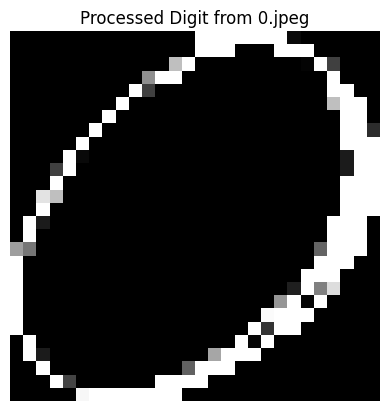

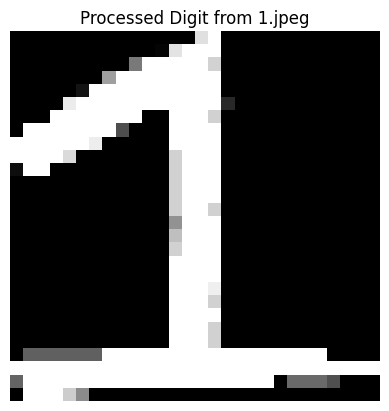

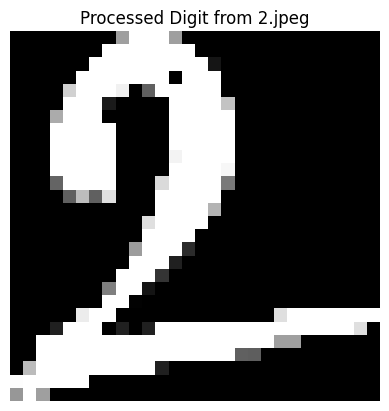

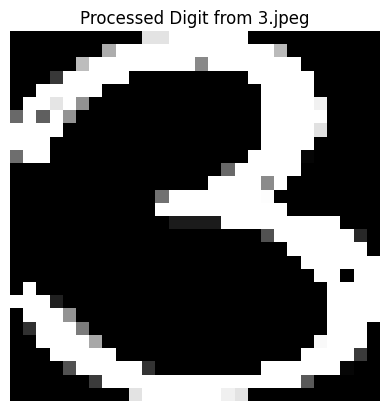

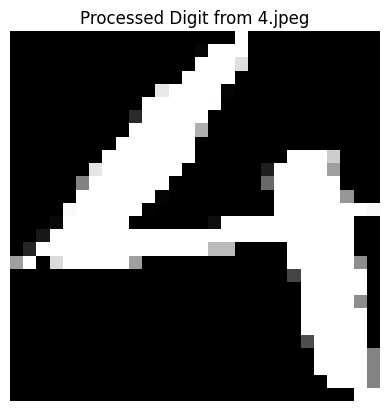

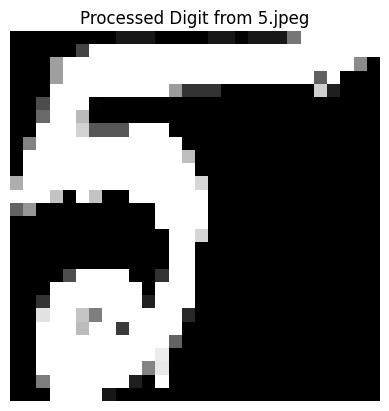

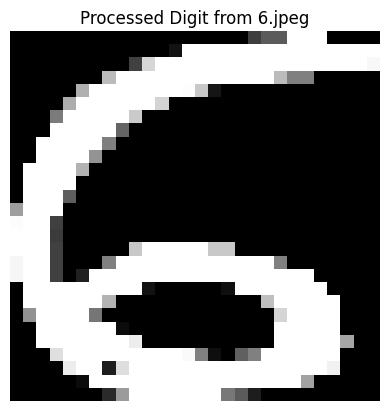

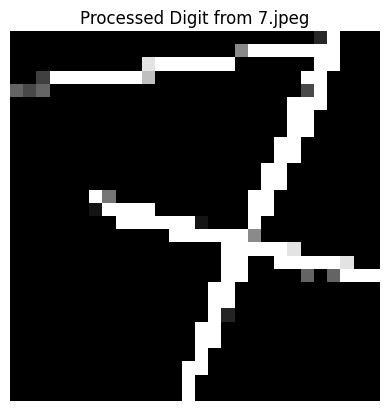

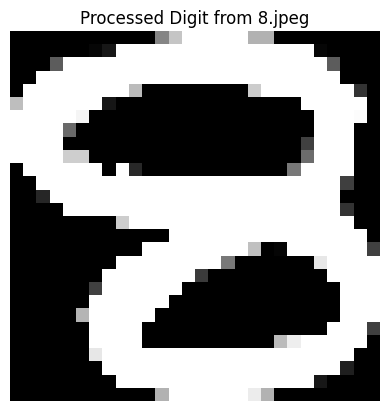

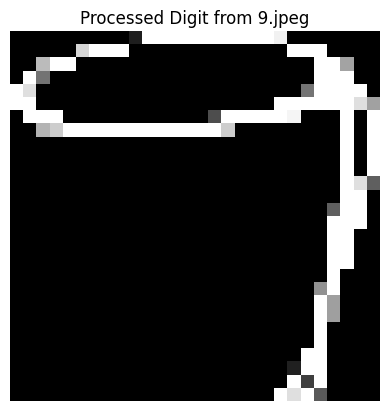

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_dir = '/content/sample_data/Handwritten Digits'

image_files = sorted(os.listdir(image_dir))

for image_file in image_files:
    image_path = os.path.join(image_dir, image_file)

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Error: Could not load {image_file}. Skipping...")
        continue

    _, thresh = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        contour = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(contour)
        digit = thresh[y:y+h, x:x+w]
        digit_resized = cv2.resize(digit, (28, 28))


        digit_normalized = digit_resized.astype('float32') / 255.0


        digit_final = digit_normalized.reshape(1, 28, 28, 1)
        plt.imshow(digit_resized, cmap='gray')
        plt.axis('off')
        plt.title(f"Processed Digit from {image_file}")
        plt.show()

    else:
        print(f"No digit found in {image_file}. Skipping...")


Available images: ['0.jpeg', '1.jpeg', '2.jpeg', '3.jpeg', '4.jpeg', '5.jpeg', '6.jpeg', '7.jpeg', '8.jpeg', '9.jpeg']

Enter image filename to check (or 'exit' to stop): 1.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


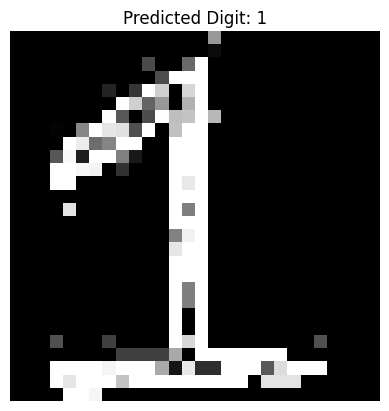

Image: 1.jpeg --> Predicted Digit: 1

Enter image filename to check (or 'exit' to stop): 7.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


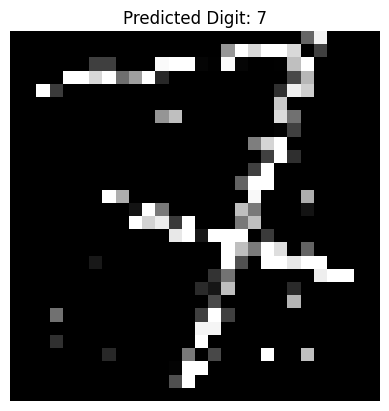

Image: 7.jpeg --> Predicted Digit: 7

Enter image filename to check (or 'exit' to stop): exit

Program ended.


In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

model = load_model('/content/mnist_cnn_model.keras')

image_dir = "/content/sample_data/Handwritten Digits"
image_files = sorted(os.listdir(image_dir))

print("Available images:", image_files)

while True:
    image_file = input("\nEnter image filename to check (or 'exit' to stop): ")

    if image_file.lower() == 'exit':
        break

    image_path = os.path.join(image_dir, image_file)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Error: Could not load {image_file}. Please try again.")
        continue
    thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(contour)
        digit = thresh[y:y+h, x:x+w]
        aspect_ratio = w / h
        if aspect_ratio > 1:
            new_w, new_h = 28, int(28 / aspect_ratio)
        else:
            new_w, new_h = int(28 * aspect_ratio), 28

        digit_resized = cv2.resize(digit, (new_w, new_h))

        digit_padded = np.zeros((28, 28), dtype=np.uint8)
        start_x = (28 - new_w) // 2
        start_y = (28 - new_h) // 2
        digit_padded[start_y:start_y+new_h, start_x:start_x+new_w] = digit_resized
        digit_normalized = digit_padded.astype('float32') / 255.0

        digit_final = digit_normalized.reshape(1, 28, 28, 1)

        prediction = model.predict(digit_final)
        predicted_digit = np.argmax(prediction)

        plt.imshow(digit_padded, cmap='gray')
        plt.title(f"Predicted Digit: {predicted_digit}")
        plt.axis("off")
        plt.show()

        print(f"Image: {image_file} --> Predicted Digit: {predicted_digit}")

    else:
        print(f"No digit found in {image_file}! Try another image.")

print("\nProgram ended.")